In [31]:
import numpy as np
import matplotlib.pyplot as plt

In [32]:
X=np.random.randint(size=(10000,2),high=999,low=-999)
print(X)

[[ 104  869]
 [ 486 -819]
 [ 460  796]
 ...
 [-939 -630]
 [ 528 -179]
 [-793 -566]]


In [33]:
SumX = np.sum(X,axis=1)
print(SumX)

[  973  -333  1256 ... -1569   349 -1359]


In [34]:
y = [] # tre classi di etichette: negativo, zero, positivo
for i in range(len(SumX)):
    if SumX[i] < 0:
        y.append([1,0,0])
    if SumX[i] == 0:
        y.append([0,1,0])
    if SumX[i] > 0:
        y.append([0,0,1])

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchsummary import summary

In [36]:
# Impostiamo il dispositivo su cui eseguire il codice (GPU, se disponibile)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [37]:
# Definiamo la classe Dataset di PyTorch
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.x = torch.tensor(X,dtype=torch.float32)
        self.y = torch.tensor(Y,dtype=torch.float32)
        self.len = self.x.shape[0]

    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [38]:
#Creiamo i DataSet
perc =0.8 # percentuale di dati per il training
n = int(10000 * perc)
train_dataset = Dataset(X[:n,:], y[:n])
test_dataset  = Dataset(X[n:,:], y[n:])

In [39]:
# Creiamo i DataLoader per gestire i batch
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

In [40]:
class DenseNN(nn.Module):
    def __init__(self):
        super(DenseNN, self).__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 3)

    def forward(self, x):
        x = torch.relu(self.fc1(x))      # Applichiamo ReLU dopo il primo strato
        x = torch.relu(self.fc2(x))      # Applichiamo ReLU dopo il secondo strato
        x = self.fc3(x)                  # Strato finale (senza attivazione, poiché Softmax è implicito nella funzione di perdita)
        return x

In [41]:
model = DenseNN().to(device)  # Spostiamo il modello sul dispositivo scelto
criterion = nn.CrossEntropyLoss()  # Funzione di perdita per problemi di classificazione
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Ottimizzatore Adam

In [42]:
# Funzione per stampare il modello e visualizzare il numero totale di parametri
def visualizza_modello(model, input_size):
    print("Struttura della rete neurale:")
    print(model)
    print("\nRiassunto del modello:")
    summary(model, input_size=input_size)

In [43]:
# Visualizziamo la rete e il numero di parametri
visualizza_modello(model, input_size=(1, 2))

Struttura della rete neurale:
DenseNN(
  (fc1): Linear(in_features=2, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=3, bias=True)
)

Riassunto del modello:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 64]             192
            Linear-2                [-1, 1, 64]           4,160
            Linear-3                 [-1, 1, 3]             195
Total params: 4,547
Trainable params: 4,547
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.02
Estimated Total Size (MB): 0.02
----------------------------------------------------------------


Epoch 1/100, Loss: 11.1447
Epoch 2/100, Loss: 0.0273
Epoch 3/100, Loss: 0.0234
Epoch 4/100, Loss: 0.0208
Epoch 5/100, Loss: 0.0186
Epoch 6/100, Loss: 0.0164
Epoch 7/100, Loss: 0.0146
Epoch 8/100, Loss: 0.0131
Epoch 9/100, Loss: 0.0114
Epoch 10/100, Loss: 0.0111
Epoch 11/100, Loss: 0.0104
Epoch 12/100, Loss: 0.0118
Epoch 13/100, Loss: 0.0130
Epoch 14/100, Loss: 0.0134
Epoch 15/100, Loss: 0.0109
Epoch 16/100, Loss: 0.0140
Epoch 17/100, Loss: 0.0116
Epoch 18/100, Loss: 0.0115
Epoch 19/100, Loss: 0.0102
Epoch 20/100, Loss: 0.0091
Epoch 21/100, Loss: 0.0090
Epoch 22/100, Loss: 0.0078
Epoch 23/100, Loss: 0.0101
Epoch 24/100, Loss: 0.0080
Epoch 25/100, Loss: 0.0079
Epoch 26/100, Loss: 0.0145
Epoch 27/100, Loss: 0.0113
Epoch 28/100, Loss: 0.0088
Epoch 29/100, Loss: 0.0091
Epoch 30/100, Loss: 0.0073
Epoch 31/100, Loss: 0.0100
Epoch 32/100, Loss: 0.0085
Epoch 33/100, Loss: 0.0104
Epoch 34/100, Loss: 0.0087
Epoch 35/100, Loss: 0.0138
Epoch 36/100, Loss: 0.0298
Epoch 37/100, Loss: 0.0063
Epoch 38/

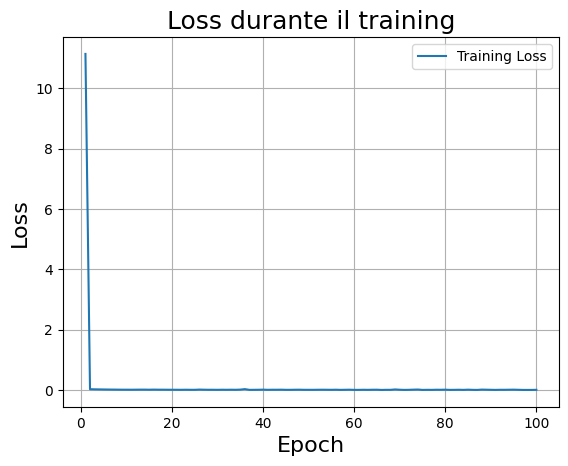

In [44]:
epochs = 100
train_losses = []

for epoch in range(epochs):
    model.train()  # Mettiamo il modello in modalità training
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)  # Spostiamo i dati sul dispositivo

        optimizer.zero_grad()  # Azzeriamo i gradienti
        outputs = model(inputs)  # Forward pass
        #print(outputs,labels)
        loss = criterion(outputs, labels)  # Calcoliamo la perdita
        loss.backward()  # Backward pass
        optimizer.step()  # Aggiorniamo i pesi

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

# Visualizziamo l'andamento della perdita durante il training
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.title('Loss durante il training', fontsize=18)
plt.grid()
plt.legend()
plt.show()

In [45]:
model.eval()  # Mettiamo il modello in modalità valutazione
correct = 0
total = 0
misclassified = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)  # Prevediamo la classe con probabilità più alta
        #print(labels)
        true_class = torch.argmax(labels,axis=1)
        #print(predicted,true_class)
        total += labels.size(0)
        correct += (predicted == true_class).sum().item()

        # Salviamo alcune immagini mal classificate
        for i in range(inputs.size(0)):
            if predicted[i] != true_class[i]:
                misclassified.append((inputs[i].cpu(), predicted[i].item(), true_class[i].item()))

accuracy = 100 * correct / total
print(f'Accuracy sul test set: {accuracy:.2f}%')

Accuracy sul test set: 99.90%
